# Q1. Supervised Learning: Heart Disease Prediction

This notebook builds classification models to predict whether a patient has heart disease.
Target column: `heart_disease`

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score

In [5]:
df = pd.read_csv("q1_heart_disease.csv")

print("Shape of dataset:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

df.head()

Shape of dataset: (800, 12)

Data types:
age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

Missing values:
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


The dataset has patient-level medical records. The target variable is `heart_disease`, where 1 means disease is present and 0 means absent. Some columns are numerical, while columns like chest pain type, resting ECG, and ST slope are categorical.

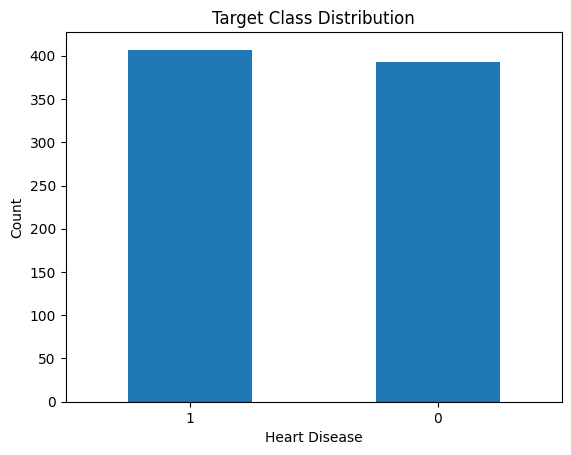

In [6]:
df["heart_disease"].value_counts().plot(kind="bar")
plt.title("Target Class Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

The target distribution shows how many patients have heart disease and how many do not. This helps check whether the classification problem is balanced or imbalanced.

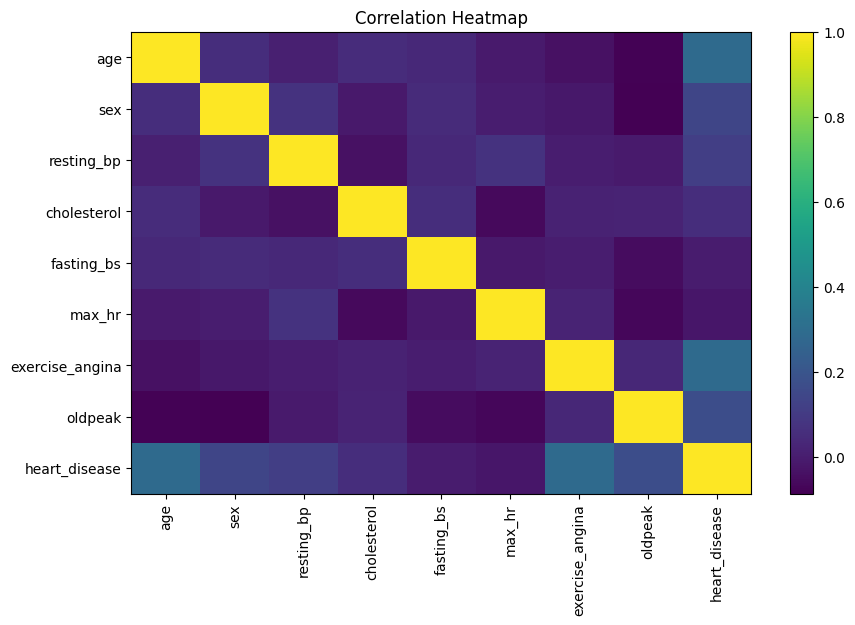

In [7]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10, 6))
plt.imshow(numeric_df.corr(), aspect="auto")
plt.colorbar()
plt.xticks(range(len(numeric_df.columns)), numeric_df.columns, rotation=90)
plt.yticks(range(len(numeric_df.columns)), numeric_df.columns)
plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap shows relationships between numerical features and the target variable. Features with stronger positive or negative correlation with `heart_disease` may be more useful for prediction.

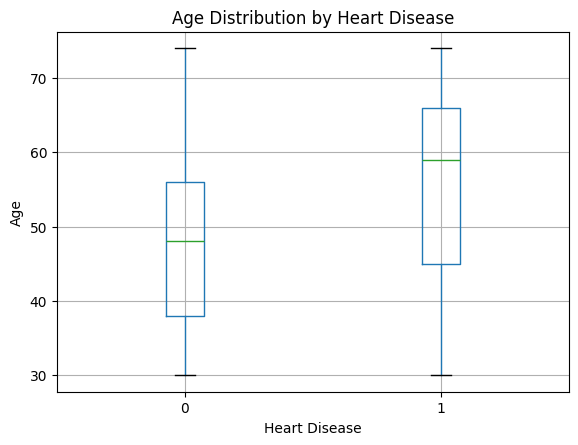

In [8]:
df.boxplot(column="age", by="heart_disease")
plt.title("Age Distribution by Heart Disease")
plt.suptitle("")
plt.xlabel("Heart Disease")
plt.ylabel("Age")
plt.show()

This plot compares the age distribution of patients with and without heart disease. It helps understand whether heart disease is more common in older patients.

In [9]:
X = df.drop("heart_disease", axis=1)
y = df["heart_disease"]

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

Categorical features: ['chest_pain_type', 'resting_ecg', 'st_slope']
Numerical features: ['age', 'sex', 'resting_bp', 'cholesterol', 'fasting_bs', 'max_hr', 'exercise_angina', 'oldpeak']


Missing values are handled using median imputation for numerical columns because median is less affected by extreme values. Categorical variables are converted using one-hot encoding, and numerical features are scaled using StandardScaler.

In [11]:
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (640, 11)
Test set: (160, 11)


In [13]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

trained_models = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    trained_models[name] = pipeline

    print(name, "trained successfully")

Decision Tree trained successfully
Random Forest trained successfully
Gradient Boosting trained successfully


In [14]:
results = {}

for name, pipeline in trained_models.items():
    y_pred = pipeline.predict(X_test)

    print("="*50)
    print(name)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    results[name] = f1_score(y_test, y_pred)

print("\nF1 Scores:")
print(results)

Decision Tree
Confusion Matrix:
[[56 23]
 [22 59]]

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.71      0.71        79
           1       0.72      0.73      0.72        81

    accuracy                           0.72       160
   macro avg       0.72      0.72      0.72       160
weighted avg       0.72      0.72      0.72       160

Random Forest
Confusion Matrix:
[[60 19]
 [15 66]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.76      0.78        79
           1       0.78      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160

Gradient Boosting
Confusion Matrix:
[[61 18]
 [18 63]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.77      0.77        79
        

The best model is selected mainly using F1-score because this is a medical classification problem where both precision and recall are important. Accuracy alone may be misleading if one class is easier to predict. The model with the highest F1-score gives the best balance between correctly identifying heart disease cases and avoiding false predictions.

In [15]:
best_model_name = max(results, key=results.get)
print("Best model based on F1-score:", best_model_name)

Best model based on F1-score: Random Forest


In [16]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

param_grid = {
    "model__n_estimators": [50, 100, 150],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

Best parameters:
{'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 150}


In [17]:
baseline_rf = trained_models["Random Forest"]
baseline_pred = baseline_rf.predict(X_test)
baseline_f1 = f1_score(y_test, baseline_pred)

tuned_pred = grid_search.best_estimator_.predict(X_test)
tuned_f1 = f1_score(y_test, tuned_pred)

print("Untuned Random Forest F1-score:", baseline_f1)
print("Tuned Random Forest F1-score:", tuned_f1)

print("\nTuned Model Confusion Matrix:")
print(confusion_matrix(y_test, tuned_pred))

print("\nTuned Model Classification Report:")
print(classification_report(y_test, tuned_pred))

Untuned Random Forest F1-score: 0.7951807228915663
Tuned Random Forest F1-score: 0.8072289156626506

Tuned Model Confusion Matrix:
[[61 18]
 [14 67]]

Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.77      0.79        79
           1       0.79      0.83      0.81        81

    accuracy                           0.80       160
   macro avg       0.80      0.80      0.80       160
weighted avg       0.80      0.80      0.80       160



GridSearchCV was used to tune the Random Forest model. The tuned model was compared with the untuned baseline using F1-score. If the tuned model has a higher F1-score, it improves the balance between precision and recall. If the score is similar, the simpler untuned model may still be acceptable.